# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters? **Penalty charges model for having large coeffficients, increasing MSE i nproportion to coefficient size, discourages overfitting**
2. How does regularization provide a way of exploring the bias-variance trade-off? **higher alpha results in a steeper penalty which results in a coefficients shrinker towards zero and a lower variance. a lower alpha has a lower penalty, making the model more complex and less bias, with more variance**
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems? **LASSO sends coefficients exactly to zero, while LASSO smoothly shrinks all coefficients towards zero. LASSO is better for interpretable modesl and Ridge is better for predictons**.
4. How do we typically scale variables for use in regularized regression? Why? **z score normalize numeric values. The penalty compares variables by how much power for each unit of coefficient, this means that differing scales can inflate or deflate that comparison**
5. How is the penalty $\alpha$ typically selected? **selected through cross validation**
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not? **no, penalty term is for regularization not prediction error.**

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`? **Sign of Milege_run_age, its negative**
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? **6/9 selected; 3/9 (33.3%) zeroed out: Age^2, Mileage_Run^3, Mileage_Run^2 Age are dropped**
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? **For magnitude, age becomes more negative. For signs, Age^3 changes sign from negative to positive**

Features: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
Shape: (976, 9)
          feature      OLS_coef
      Mileage_Run  6.686165e+05
              Age -1.841941e+05
    Mileage_Run^2 -1.494679e+05
  Mileage_Run Age -1.251592e+06
            Age^2  2.156399e+05
    Mileage_Run^3 -6.514490e+04
Mileage_Run^2 Age  2.833392e+05
Mileage_Run Age^2  5.280829e+05
            Age^3 -1.389370e+05
Optimal alpha: 1000.0000
          feature     Lasso_coef
      Mileage_Run  401025.259657
              Age -194803.116695
    Mileage_Run^2  -62539.290093
  Mileage_Run Age -578788.661090
            Age^2      -0.000000
    Mileage_Run^3      -0.000000
Mileage_Run^2 Age       0.000000
Mileage_Run Age^2  292015.025679
            Age^3   19133.908573
Optimal alpha: 1000.0000


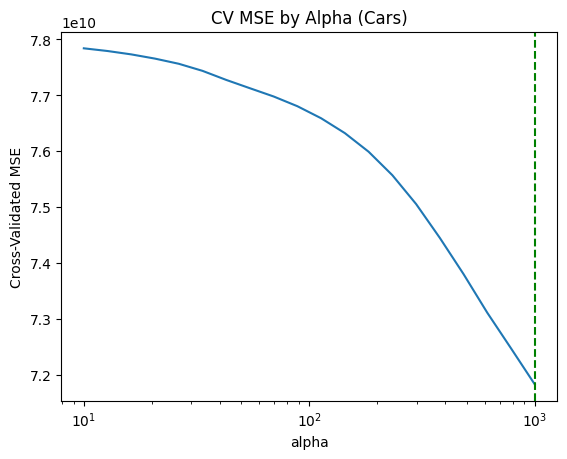

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.408e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.686e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.202e+11, tolerance: 1.316e

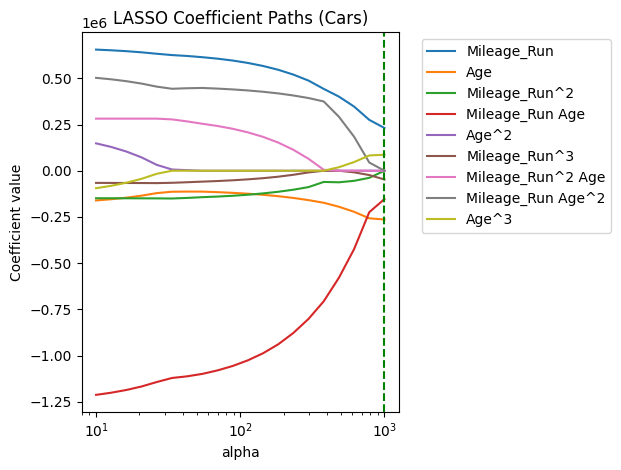

Selected: 6/9
Zeroed out: 3/9 (33.3%)

Selected features:
  Mileage_Run: 401025.26
  Age: -194803.12
  Mileage_Run^2: -62539.29
  Mileage_Run Age: -578788.66
  Mileage_Run Age^2: 292015.03
  Age^3: 19133.91
          feature         OLS      LASSO  mag_increase  sign_change
      Mileage_Run   668616.52  401025.26         False        False
              Age  -184194.15 -194803.12          True        False
    Mileage_Run^2  -149467.87  -62539.29         False        False
  Mileage_Run Age -1251592.34 -578788.66         False        False
            Age^2   215639.88      -0.00         False        False
    Mileage_Run^3   -65144.90      -0.00         False        False
Mileage_Run^2 Age   283339.15       0.00         False        False
Mileage_Run Age^2   528082.86  292015.03         False        False
            Age^3  -138937.03   19133.91         False         True


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

df = pd.read_csv('/content/cars_hw.csv', index_col=0)
df['Age'] = 2024 - df['Make_Year']

X_raw = df[['Mileage_Run', 'Age']].values
y = df['Price'].values

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

print('Features:', feature_names)
print('Shape:', X_scaled.shape)

lr = LinearRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({'feature': feature_names, 'OLS_coef': lr.coef_})
print(coef_df.to_string(index=False))

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000, random_state=100)
lasso_cv.fit(X_scaled, y)

index_star = np.argmin(np.median(lasso_cv.mse_path_, axis=1))
alpha_star = lasso_cv.alphas_[index_star]

print(f'Optimal alpha: {alpha_star:.4f}')

lasso_coef_df = pd.DataFrame({'feature': feature_names, 'Lasso_coef': lasso_cv.coef_})
print(lasso_coef_df.to_string(index=False))

sns.lineplot(x=lasso_cv.alphas_, y=np.median(lasso_cv.mse_path_, axis=1))
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-Validated MSE')
plt.title('CV MSE by Alpha (Cars)')
print(f'Optimal alpha: {alpha_star:.4f}')
plt.show()

coef_paths = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_scaled, y)
    coef_paths.append(model.coef_)
coef_paths = np.array(coef_paths)

plt.figure()
for i in range(coef_paths.shape[1]):
    plt.plot(alphas, coef_paths[:, i], label=feature_names[i])
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths (Cars)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

n_zero = np.sum(lasso_cv.coef_ == 0)
n_total = len(lasso_cv.coef_)
print(f'Selected: {n_total - n_zero}/{n_total}')
print(f'Zeroed out: {n_zero}/{n_total} ({n_zero/n_total*100:.1f}%)')
print('\nSelected features:')
for name, coef in zip(feature_names, lasso_cv.coef_):
    if coef != 0:
        print(f'  {name}: {coef:.2f}')

compare_df = pd.DataFrame({
    'feature': feature_names,
    'OLS': np.round(lr.coef_, 2),
    'LASSO': np.round(lasso_cv.coef_, 2)
})
compare_df['mag_increase'] = compare_df['LASSO'].abs() > compare_df['OLS'].abs()
compare_df['sign_change'] = (
    (np.sign(compare_df['OLS']) != np.sign(compare_df['LASSO'])) &
    (compare_df['LASSO'] != 0)
)
print(compare_df.to_string(index=False))

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction? **smoking, diabetes, high_blood_pressure, and anaemia all have negative coefficients which is counterintuitive, most likely due to multicollinearity, having higher order interactiosn can resolive this contradiction, forexample, diabetes high blood pressure and diabetes smoking have large positive coefficients showing that the combined effect makes sense **
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off. **12/33 selected; 21/33 (63.6%) zeroed out Serum_creatinine^3 changes in magnitude, becoming more negative, and serum_creatinine, ejection_fraction^3, ejection_fraction^2 serum_creatinine, anaemia, diabetes, high_blood_pressure all flip signs, LASSO signs make more sense, with only ejection fraction as negative and the rest positive, which makes logical lense, OLS probably had issues with multicollinearity, demonstrating bias variance trade off, LASSO has small bias in exchange for lower variance  **

Total features: 33
Continuous polynomial features: ['age' 'ejection_fraction' 'serum_creatinine' 'age^2'
 'age ejection_fraction' 'age serum_creatinine' 'ejection_fraction^2'
 'ejection_fraction serum_creatinine' 'serum_creatinine^2' 'age^3'
 'age^2 ejection_fraction' 'age^2 serum_creatinine'
 'age ejection_fraction^2' 'age ejection_fraction serum_creatinine'
 'age serum_creatinine^2' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine'
 'ejection_fraction serum_creatinine^2' 'serum_creatinine^3']
Categorical interaction features: ['anaemia' 'diabetes' 'high_blood_pressure' 'smoking' 'anaemia diabetes'
 'anaemia high_blood_pressure' 'anaemia smoking'
 'diabetes high_blood_pressure' 'diabetes smoking'
 'high_blood_pressure smoking' 'anaemia diabetes high_blood_pressure'
 'anaemia diabetes smoking' 'anaemia high_blood_pressure smoking'
 'diabetes high_blood_pressure smoking']
                               feature  OLS_coef
                                   age    1.5499
      

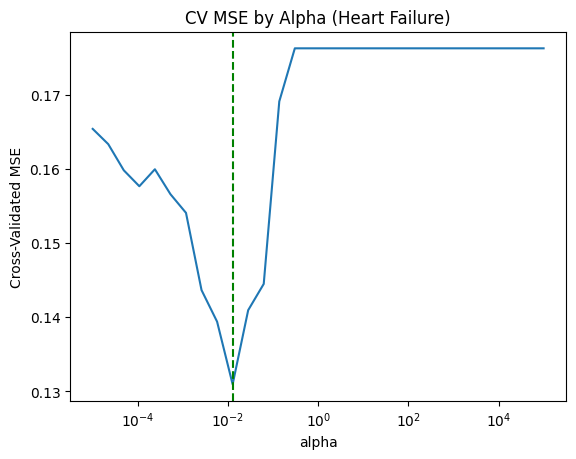

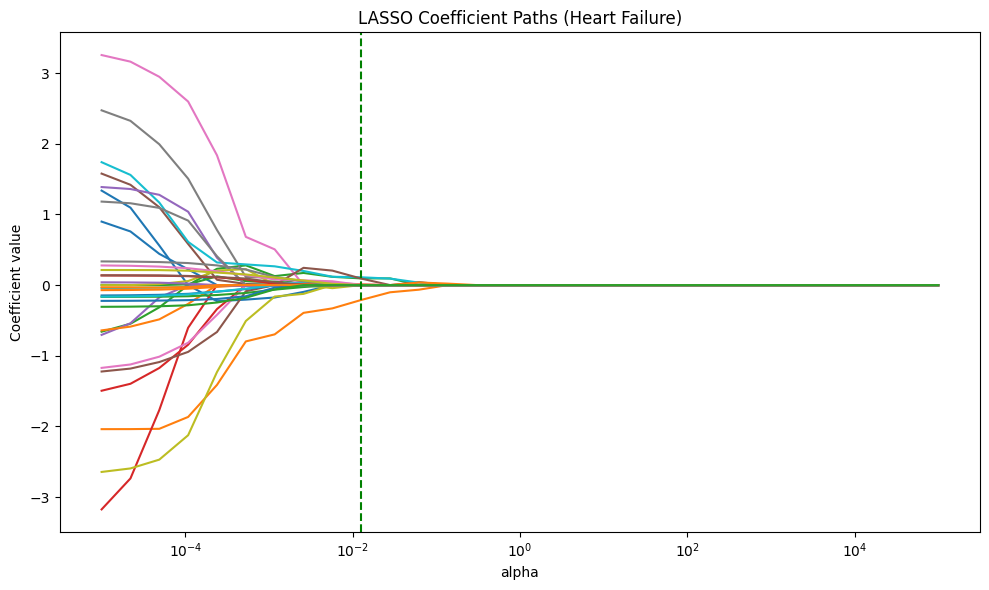

Selected: 12/33
Zeroed out: 21/33 (63.6%)

                               feature     OLS   LASSO  mag_increase  sign_change
                                   age  1.5499 -0.0000         False        False
                     ejection_fraction -2.0254 -0.3297         False        False
                      serum_creatinine -0.7390  0.1169         False         True
                                 age^2 -3.5480  0.0000         False        False
                 age ejection_fraction -0.8619 -0.0000         False        False
                  age serum_creatinine  1.6806  0.0000         False        False
                   ejection_fraction^2  3.3179  0.0000         False        False
    ejection_fraction serum_creatinine  2.6048  0.0000         False        False
                    serum_creatinine^2 -2.7031 -0.0000         False        False
                                 age^3  1.8890  0.1180         False        False
               age^2 ejection_fraction  1.0220  0.0000 

In [40]:
hf = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')
y_hf = hf['DEATH_EVENT'].values

continuous = ['age', 'ejection_fraction', 'serum_creatinine']
categorical = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly_cont.fit_transform(hf[continuous].values)
cont_names = poly_cont.get_feature_names_out(continuous)
scaler_hf = StandardScaler()
X_cont_scaled = scaler_hf.fit_transform(X_cont)

poly_cat = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(hf[categorical].values)
cat_names = poly_cat.get_feature_names_out(categorical)

X_hf = np.concatenate([X_cont_scaled, X_cat], axis=1)
all_names = np.concatenate([cont_names, cat_names])

print('Total features:', len(all_names))
print('Continuous polynomial features:', cont_names)
print('Categorical interaction features:', cat_names)

lr_hf = LinearRegression()
lr_hf.fit(X_hf, y_hf)

coef_hf = pd.DataFrame({'feature': all_names, 'OLS_coef': np.round(lr_hf.coef_, 4)})
print(coef_hf.to_string(index=False))

alphas_hf = np.logspace(-5, 5, 30)

lasso_hf = LassoCV(alphas=alphas_hf, cv=20, max_iter=100000, random_state=100)
lasso_hf.fit(X_hf, y_hf)

index_star_hf = np.argmin(np.median(lasso_hf.mse_path_, axis=1))
alpha_star_hf = lasso_hf.alphas_[index_star_hf]

print(f'Optimal alpha: {alpha_star_hf:.6f}')

lasso_hf_df = pd.DataFrame({'feature': all_names, 'Lasso_coef': np.round(lasso_hf.coef_, 4)})
print(lasso_hf_df.to_string(index=False))

sns.lineplot(x=lasso_hf.alphas_, y=np.median(lasso_hf.mse_path_, axis=1))
plt.axvline(x=alpha_star_hf, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-Validated MSE')
plt.title('CV MSE by Alpha (Heart Failure)')
print(f'Optimal alpha: {alpha_star_hf:.6f}')
plt.show()

coef_paths_hf = []
for alpha in alphas_hf:
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_hf, y_hf)
    coef_paths_hf.append(model.coef_)
coef_paths_hf = np.array(coef_paths_hf)

plt.figure(figsize=(10, 6))
for i in range(coef_paths_hf.shape[1]):
    plt.plot(alphas_hf, coef_paths_hf[:, i], label=all_names[i])
plt.axvline(x=alpha_star_hf, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths (Heart Failure)')
plt.tight_layout()
plt.show()

n_zero_hf = np.sum(lasso_hf.coef_ == 0)
n_total_hf = len(lasso_hf.coef_)
print(f'Selected: {n_total_hf - n_zero_hf}/{n_total_hf}')
print(f'Zeroed out: {n_zero_hf}/{n_total_hf} ({n_zero_hf/n_total_hf*100:.1f}%)')

compare_hf = pd.DataFrame({
    'feature': all_names,
    'OLS': np.round(lr_hf.coef_, 4),
    'LASSO': np.round(lasso_hf.coef_, 4)
})
compare_hf['mag_increase'] = compare_hf['LASSO'].abs() > compare_hf['OLS'].abs()
compare_hf['sign_change'] = (
    (np.sign(compare_hf['OLS']) != np.sign(compare_hf['LASSO'])) &
    (compare_hf['LASSO'] != 0)
)
print()
print(compare_hf.to_string(index=False))

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem? $$
\frac{1}{n}\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2
$$
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

**b1 = (Σ x̃ᵢỹᵢ) / (Σ x̃ᵢ² + nα)**,    
3. How does increasing $\alpha$ change the slope coefficient? **larger alpha results in a larger denominator, which shrinks slope coefficient towards 0**

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$? **because LASSO requires absolute value so can't be differentiable at b1=0, It is optimal to set b 1 =0 when a variable's predictive power is too weak to justify paying the penalty cost α**